# Week 6 - Spark Architecture and Advanced Data Processing

## Objective

The objective of this assignment is to understand the basic architecture of Apache Spark and learn how to process data using PySpark. In this assignment, I performed data loading, filtering, transformations, and worked with different file formats while understanding some basic Spark performance concepts.

## Environment Setup

For this assignment, I used PySpark with Jupyter Notebook in Visual Studio Code. A Spark Session was created to perform all the required DataFrame operations.

In [15]:
import pyspark

print("PySpark Version:", pyspark.__version__)

PySpark Version: 4.2.0


In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

In [ ]:
spark = SparkSession.builder \
    .appName("Week6_Spark_Architecture") \
    .getOrCreate()

c:\Users\SANGITA\OneDrive\Desktop\Celebal-Summer-Internship-2026\.venv\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [16]:
print("Spark Version:", spark.version)

Spark Version: 4.2.0


## Dataset Preparation

For this assignment, I used a grocery inventory dataset. The dataset contains product information, supplier details, stock quantity, unit price, warehouse location, sales volume, and inventory status. This dataset will be used throughout the assignment.

https://www.kaggle.com/datasets/salahuddinahmedshuvo/grocery-inventory-and-sales-dataset

# Step 1 - Understand Spark Architecture

In this step, I learned about the basic components of Apache Spark and how they work together during data processing.

## Q1. Explain the roles of the Driver, Cluster Manager, and Executor in a Spark application.

**Driver**

The Driver is the main program of a Spark application. It creates the Spark Session, manages the execution process, and sends tasks to the executors.

**Cluster Manager**

The Cluster Manager is responsible for allocating the required resources for the Spark application.

**Executor**

Executors run on worker nodes. They perform the assigned tasks and send the results back to the Driver.

### Result

I understood the role of the Driver, Cluster Manager, and Executors in a Spark application.

## Q2. How does Spark's Lazy Evaluation strategy improve performance when chain-processing large datasets?

Spark uses Lazy Evaluation, which means it does not execute transformations immediately. Instead, Spark records the transformations and creates an execution plan. The transformations are executed only when an action such as `show()` or `count()` is called. This helps reduce unnecessary processing and improves performance.

In [18]:
from pyspark.sql.functions import col

inventory_df = spark.read.csv(
    "../dataset/Grocery_Inventory_and_Sales_Dataset.csv",
    header=True,
    inferSchema=True
)

lazy_df = inventory_df.filter(
    col("Status") == "Active"
).select(
    "Product_ID",
    "Product_Name",
    "Stock_Quantity"
)

print("Transformations created successfully.")

Transformations created successfully.


In [19]:
lazy_df.show()

+-----------+---------------+--------------+
| Product_ID|   Product_Name|Stock_Quantity|
+-----------+---------------+--------------+
|71-594-6552|Long Grain Rice|            12|
|71-516-1996|       Corn Oil|            96|
|66-268-8345|   Greek Yogurt|            91|
|46-452-9419|     Egg (Duck)|            43|
|11-073-0189|           Plum|            95|
|22-621-2774|   Strawberries|            54|
|55-936-2406|    Bread Flour|            27|
|48-414-6162| Arabica Coffee|            55|
|66-627-9752|          Trout|            49|
|67-025-1245|        Cabbage|            88|
|68-418-6724|Parmesan Cheese|            63|
|79-741-0770|      Mushrooms|            72|
|91-848-0606|          Onion|            39|
|70-854-6891|Sourdough Bread|            41|
|36-918-2937|   Green Coffee|            62|
|69-468-5468|Sourdough Bread|            59|
|41-729-5410|       Sardines|            91|
|33-335-9140|      Olive Oil|            28|
|78-237-0277|      Black Tea|            46|
|65-718-04

### Result

The transformations were created first, and Spark executed them only after calling the `show()` action. This demonstrates Spark's Lazy Evaluation feature.

# Step 2 - Read Data

In this step, I loaded the dataset into a Spark DataFrame. I used the `header=True` option to read the first row as column names and `inferSchema=True` to automatically detect the data types of each column.

## Q3. Write a Spark command to read a CSV file located at "data/source.csv", ensuring the first row is treated as a header and inferSchema is enabled.

The dataset is loaded using the `read.csv()` function. The `header=True` option treats the first row as column names, while `inferSchema=True` automatically detects the data type of each column.

In [20]:
inventory_df = spark.read.csv(
    "../dataset/Grocery_Inventory_and_Sales_Dataset.csv",
    header=True,
    inferSchema=True
)

inventory_df.show(5)

+-----------+---------------+-------------------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+--------------------+------------+-----------------------+------------+
| Product_ID|   Product_Name|           Catagory|Supplier_ID|Supplier_Name|Stock_Quantity|Reorder_Level|Reorder_Quantity|Unit_Price|Date_Received|Last_Order_Date|Expiration_Date|  Warehouse_Location|Sales_Volume|Inventory_Turnover_Rate|      Status|
+-----------+---------------+-------------------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+--------------------+------------+-----------------------+------------+
|29-205-1132|     Sushi Rice|    Grains & Pulses|38-037-1699|    Jaxnation|            22|           72|              70|    $4.50 |    8/16/2024|      6/29/2024|      9/19/2024|    48 Del Sol Trail|          32|                     19|Discontinued|


In [21]:
inventory_df.printSchema()

root
 |-- Product_ID: string (nullable = true)
 |-- Product_Name: string (nullable = true)
 |-- Catagory: string (nullable = true)
 |-- Supplier_ID: string (nullable = true)
 |-- Supplier_Name: string (nullable = true)
 |-- Stock_Quantity: integer (nullable = true)
 |-- Reorder_Level: integer (nullable = true)
 |-- Reorder_Quantity: integer (nullable = true)
 |-- Unit_Price: string (nullable = true)
 |-- Date_Received: string (nullable = true)
 |-- Last_Order_Date: string (nullable = true)
 |-- Expiration_Date: string (nullable = true)
 |-- Warehouse_Location: string (nullable = true)
 |-- Sales_Volume: integer (nullable = true)
 |-- Inventory_Turnover_Rate: integer (nullable = true)
 |-- Status: string (nullable = true)



### Result

The dataset was loaded successfully. Spark displayed the first few records and automatically detected the schema of the dataset.

# Step 3 - File Formats

In this step, I learned about the difference between CSV and Parquet file formats and understood which format is better for analytical workloads.

## Q4. Compare the benefits of storing data in Parquet format versus CSV format for analytical workloads.

**CSV**
- Easy to read and share.
- Stores data as plain text.
- Takes more storage space.
- Reads the entire file during processing.

**Parquet**
- Stores data in a column-based format.
- Uses compression, so it requires less storage space.
- Reads only the required columns.
- Faster for analytical queries in Spark.

### Result

I learned that CSV files are simple and easy to use, while Parquet files are more efficient for storing and processing large datasets in Spark.

# Step 4 - Data Selection and Filtering

In this step, I selected the required columns from the dataset and filtered the records using different conditions. This helps in working only with the required data.

## Q5. Given a DataFrame named `df_products`, write a query to select only the `product_id`, `product_name`, and `price` columns.

The `select()` function is used to display only the required columns from a DataFrame.

In [22]:
selected_products = inventory_df.select(
    "Product_ID",
    "Product_Name",
    "Unit_Price"
)

selected_products.show()

+-----------+-----------------+----------+
| Product_ID|     Product_Name|Unit_Price|
+-----------+-----------------+----------+
|29-205-1132|       Sushi Rice|    $4.50 |
|40-681-9981|   Arabica Coffee|   $20.00 |
|06-955-3428|       Black Rice|    $6.00 |
|71-594-6552|  Long Grain Rice|    $1.50 |
|57-437-1828|             Plum|    $4.00 |
|21-120-6238|All-Purpose Flour|    $1.75 |
|71-516-1996|         Corn Oil|    $2.50 |
|39-629-5554|      Egg (Goose)|    $2.50 |
|66-268-8345|     Greek Yogurt|    $3.00 |
|46-452-9419|       Egg (Duck)|    $1.00 |
|51-469-4611|  Long Grain Rice|    $1.60 |
|42-220-9305|      White Sugar|    $2.00 |
|75-094-1179|        Rye Bread|    $3.00 |
|11-073-0189|             Plum|    $4.00 |
|22-621-2774|     Strawberries|    $6.00 |
|39-449-0772|      Feta Cheese|    $7.00 |
|55-936-2406|      Bread Flour|    $1.50 |
|82-041-7211|     Swiss Cheese|    $8.00 |
|48-414-6162|   Arabica Coffee|   $20.00 |
|76-854-0095|      White Sugar|    $2.00 |
+----------

### Result

The required columns were selected successfully using the `select()` function.

## Q8. Write a Spark command to find all records where the price is greater than 100 and the stock quantity is less than 50.

Since the `Unit_Price` column contains the `$` symbol, it is first cleaned and converted into a numeric value before applying the filter condition.

In [24]:
price_df = inventory_df.withColumn(
    "Price",
    regexp_replace(col("Unit_Price"), "\\$", "").cast("double")
)

filtered_products = price_df.filter(
    (col("Price") > 100) &
    (col("Stock_Quantity") < 50)
)

filtered_products.show()

+----------+------------+--------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+------------------+------------+-----------------------+------+-----+
|Product_ID|Product_Name|Catagory|Supplier_ID|Supplier_Name|Stock_Quantity|Reorder_Level|Reorder_Quantity|Unit_Price|Date_Received|Last_Order_Date|Expiration_Date|Warehouse_Location|Sales_Volume|Inventory_Turnover_Rate|Status|Price|
+----------+------------+--------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+------------------+------------+-----------------------+------+-----+
+----------+------------+--------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+------------------+------------+-----------------------+------+-----+



### Result

The `Unit_Price` column was converted into a numeric value by removing the `$` symbol. The filter was applied successfully, but no records matched the given conditions (`Price > 100` and `Stock_Quantity < 50`).

## Q14. Write a query to filter a dataset for rows where the region is 'North' OR the priority is 'High'.

The `filter()` function can also use multiple conditions with the OR (`|`) operator. Since the current dataset does not contain `region` and `priority` columns, Therefore, similar available columns (`Status` and `Stock_Quantity`)in the dataset are used to demonstrate the same filtering operation.

In [27]:
filtered_data = inventory_df.filter(
    (col("Status") == "Active") |
    (col("Stock_Quantity") < 20)
)

filtered_data.show()

+-----------+---------------+-------------------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+--------------------+------------+-----------------------+------------+
| Product_ID|   Product_Name|           Catagory|Supplier_ID|Supplier_Name|Stock_Quantity|Reorder_Level|Reorder_Quantity|Unit_Price|Date_Received|Last_Order_Date|Expiration_Date|  Warehouse_Location|Sales_Volume|Inventory_Turnover_Rate|      Status|
+-----------+---------------+-------------------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+--------------------+------------+-----------------------+------------+
|71-594-6552|Long Grain Rice|    Grains & Pulses|63-492-7603|   Brightbean|            12|           59|              62|    $1.50 |    12/8/2024|      2/19/2025|      4/17/2024|3 Westerfield Cro...|          95|                     99|      Active|


### Result

The dataset was filtered successfully using multiple conditions with the OR (`|`) operator.

# Step 5 - Data Transformation

In this step, I transformed the data by creating new columns and changing the data type of existing columns. This makes the data easier to use for analysis.

## Q6. Write a query to create a new column called `total_value` by multiplying `price` with `stock_quantity`.

The `withColumn()` function is used to create a new column. Since the `Unit_Price` column contains the `$` symbol, it is first converted into a numeric value before performing the calculation.

In [28]:
from pyspark.sql.functions import regexp_replace, col

transformed_df = inventory_df.withColumn(
    "Price",
    regexp_replace(col("Unit_Price"), "\\$", "").cast("double")
)

transformed_df = transformed_df.withColumn(
    "Total_Value",
    col("Price") * col("Stock_Quantity")
)

transformed_df.select(
    "Product_Name",
    "Price",
    "Stock_Quantity",
    "Total_Value"
).show()

+-----------------+-----+--------------+-----------+
|     Product_Name|Price|Stock_Quantity|Total_Value|
+-----------------+-----+--------------+-----------+
|       Sushi Rice|  4.5|            22|       99.0|
|   Arabica Coffee| 20.0|            45|      900.0|
|       Black Rice|  6.0|            30|      180.0|
|  Long Grain Rice|  1.5|            12|       18.0|
|             Plum|  4.0|            37|      148.0|
|All-Purpose Flour| 1.75|            55|      96.25|
|         Corn Oil|  2.5|            96|      240.0|
|      Egg (Goose)|  2.5|            44|      110.0|
|     Greek Yogurt|  3.0|            91|      273.0|
|       Egg (Duck)|  1.0|            43|       43.0|
|  Long Grain Rice|  1.6|            62|       99.2|
|      White Sugar|  2.0|            91|      182.0|
|        Rye Bread|  3.0|            26|       78.0|
|             Plum|  4.0|            95|      380.0|
|     Strawberries|  6.0|            54|      324.0|
|      Feta Cheese|  7.0|            94|      

### Result

A new column named `Total_Value` was created successfully by multiplying the price with the stock quantity.

## Q10. Write the code to convert a timestamp column into `TimestampType`.

The `Date_Received` column is converted into `TimestampType` using the `to_timestamp()` function. A new column named `Received_Time` is created to store the converted values.

In [29]:
from pyspark.sql.functions import to_timestamp

date_df = transformed_df.withColumn(
    "Received_Time",
    to_timestamp(col("Date_Received"), "M/d/yyyy")
)

date_df.select(
    "Date_Received",
    "Received_Time"
).show()

+-------------+-------------------+
|Date_Received|      Received_Time|
+-------------+-------------------+
|    8/16/2024|2024-08-16 00:00:00|
|    11/1/2024|2024-11-01 00:00:00|
|     8/3/2024|2024-08-03 00:00:00|
|    12/8/2024|2024-12-08 00:00:00|
|     7/3/2024|2024-07-03 00:00:00|
|    12/3/2024|2024-12-03 00:00:00|
|    3/18/2024|2024-03-18 00:00:00|
|     2/3/2025|2025-02-03 00:00:00|
|    12/4/2024|2024-12-04 00:00:00|
|   11/18/2024|2024-11-18 00:00:00|
|   12/18/2024|2024-12-18 00:00:00|
|   10/19/2024|2024-10-19 00:00:00|
|   12/13/2024|2024-12-13 00:00:00|
|     4/5/2024|2024-04-05 00:00:00|
|    3/11/2024|2024-03-11 00:00:00|
|    2/27/2024|2024-02-27 00:00:00|
|   11/16/2024|2024-11-16 00:00:00|
|    9/10/2024|2024-09-10 00:00:00|
|    5/29/2024|2024-05-29 00:00:00|
|    5/31/2024|2024-05-31 00:00:00|
+-------------+-------------------+
only showing top 20 rows


### Result

The `Date_Received` column was converted into `TimestampType` successfully.

# Step 6 - Transformations and Actions

In this step, I learned the difference between transformations and actions in Spark. Transformations create a new DataFrame, while actions execute the operations and produce the final output.

## Q11. Explain the difference between transformations and actions in Spark with one example of each.

**Transformation**

A transformation creates a new DataFrame but does not execute immediately. Spark waits until an action is called.

Example: `filter()`, `select()`, `withColumn()`

**Action**

An action executes all the pending transformations and returns the final result.

Example: `show()`, `count()`, `collect()`

In [31]:
transformed_data = inventory_df.filter(
    col("Status") == "Active"
)

transformed_data.show()

+-----------+---------------+-------------------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+--------------------+------------+-----------------------+------+
| Product_ID|   Product_Name|           Catagory|Supplier_ID|Supplier_Name|Stock_Quantity|Reorder_Level|Reorder_Quantity|Unit_Price|Date_Received|Last_Order_Date|Expiration_Date|  Warehouse_Location|Sales_Volume|Inventory_Turnover_Rate|Status|
+-----------+---------------+-------------------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+--------------------+------------+-----------------------+------+
|71-594-6552|Long Grain Rice|    Grains & Pulses|63-492-7603|   Brightbean|            12|           59|              62|    $1.50 |    12/8/2024|      2/19/2025|      4/17/2024|3 Westerfield Cro...|          95|                     99|Active|
|71-516-1996|       Corn

### Result

The `filter()` function created a transformation, and the `show()` function executed it as an action to display the filtered records.

# Step 7 - Performance Concepts

In this step, I learned some basic Spark concepts related to performance and also performed simple aggregation operations on the dataset.

    ## Q7. Explain the difference between narrow and wide transformations in Spark.

**Narrow Transformation**

In a narrow transformation, each partition works independently, and data is not moved between partitions.

Examples:
- `filter()`
- `select()`

**Wide Transformation**

In a wide transformation, Spark moves data between partitions. This process is called **shuffle**, and it usually takes more time than a narrow transformation.

Examples:
- `groupBy()`
- `join()`

### Result

I understood that narrow transformations are faster because they do not require data movement, while wide transformations involve shuffling data between partitions.

## Q9. Why is it important to cache a DataFrame before performing multiple actions on it?

Caching stores the DataFrame in memory. If the same DataFrame is used multiple times, Spark can reuse it instead of reading and processing the data again. This helps improve performance.

In [32]:
cached_df = inventory_df.cache()

cached_df.count()
cached_df.show(5)

+-----------+---------------+-------------------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+--------------------+------------+-----------------------+------------+
| Product_ID|   Product_Name|           Catagory|Supplier_ID|Supplier_Name|Stock_Quantity|Reorder_Level|Reorder_Quantity|Unit_Price|Date_Received|Last_Order_Date|Expiration_Date|  Warehouse_Location|Sales_Volume|Inventory_Turnover_Rate|      Status|
+-----------+---------------+-------------------+-----------+-------------+--------------+-------------+----------------+----------+-------------+---------------+---------------+--------------------+------------+-----------------------+------------+
|29-205-1132|     Sushi Rice|    Grains & Pulses|38-037-1699|    Jaxnation|            22|           72|              70|    $4.50 |    8/16/2024|      6/29/2024|      9/19/2024|    48 Del Sol Trail|          32|                     19|Discontinued|


### Result

The DataFrame was cached successfully and reused for multiple actions.

## Q13. Write a query to calculate the minimum, maximum, and average value of the `Unit_Price` column.

Since the `Unit_Price` column contains the `$` symbol, it is converted into a numeric value before performing the calculations.

In [34]:
price_df = inventory_df.withColumn(
    "Price",
    regexp_replace(col("Unit_Price"), "\\$", "").cast("double")
)

price_df.agg(
    min("Price").alias("Minimum Price"),
    max("Price").alias("Maximum Price"),
    avg("Price").alias("Average Price")
).show()

+-------------+-------------+-----------------+
|Minimum Price|Maximum Price|    Average Price|
+-------------+-------------+-----------------+
|          0.2|        98.43|5.924191919191919|
+-------------+-------------+-----------------+



### Result

The minimum, maximum, and average prices were calculated successfully.

## Q15. Write a final processing pipeline that filters duplicate records, fills missing values, and groups the data to calculate the total revenue.

The dataset used in this assignment does not contain the `store_id` and `revenue` columns mentioned in the question. Therefore, the available columns `Supplier_Name` and `Stock_Quantity` are used to demonstrate the same Spark operations. The pipeline removes duplicate records, fills missing values, groups the data by supplier, and calculates the total stock quantity.

In [35]:
final_pipeline = inventory_df.dropDuplicates() \
    .fillna({"Stock_Quantity": 0}) \
    .groupBy("Supplier_Name") \
    .sum("Stock_Quantity")

final_pipeline.show()

+-------------+-------------------+
|Supplier_Name|sum(Stock_Quantity)|
+-------------+-------------------+
|      Jetwire|                167|
|     Jaxworks|                212|
|  Brainlounge|                 69|
|     Snaptags|                139|
|    Reallinks|                117|
|     Skipfire|                333|
|        Kamba|                280|
|     Feedfish|                195|
|       Oyondu|                245|
|        Quaxo|                155|
|     Realfire|                 10|
|   Browsezoom|                194|
|       BlogXS|                258|
| Thoughtworks|                 80|
|      Voonder|                125|
|        Einti|                219|
|    Photofeed|                 86|
|        Yabox|                196|
|    Babbleset|                 46|
|        Yodoo|                228|
+-------------+-------------------+
only showing top 20 rows


### Result
The pipeline removed duplicate records, handled missing values, grouped the data by supplier, and calculated the total stock quantity successfully.

# Step 8 - Parquet Processing

In this step, I learned how to store a Spark DataFrame in Parquet format and read it again. Parquet is a column-based file format that is commonly used in Spark because it is faster and requires less storage than CSV files.

## Q12. Read a Parquet file, filter all active products, and save the result as a CSV file.

Since the dataset is available in CSV format, it is first converted into a Parquet file. Then the Parquet file is read, filtered for active products, and the filtered result is saved as a CSV file.

In [42]:
# Write DataFrame into Parquet format
inventory_df.write \
    .format("parquet") \
    .mode("overwrite") \
    .option("path", "../output/inventory_parquet") \
    .save()

# Read the Parquet file
parquet_df = spark.read \
    .format("parquet") \
    .load("../output/inventory_parquet")

# Filter active products
active_products = parquet_df.where(
    parquet_df.Status == "Active"
)

active_products.show()

# Save filtered data as CSV
active_products.write \
    .format("csv") \
    .mode("overwrite") \
    .option("header", "true") \
    .option("path", "../output/active_products") \
    .save()

Py4JJavaError: An error occurred while calling o279.save.
: java.lang.RuntimeException: java.io.FileNotFoundException: java.io.FileNotFoundException: HADOOP_HOME and hadoop.home.dir are unset. -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProblems
	at org.apache.hadoop.util.Shell.getWinUtilsPath(Shell.java:790)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:299)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:315)
	at org.apache.hadoop.fs.RawLocalFileSystem.setPermission(RawLocalFileSystem.java:1179)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkOneDirWithMode(RawLocalFileSystem.java:861)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirsWithOptionalPermission(RawLocalFileSystem.java:901)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirs(RawLocalFileSystem.java:873)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirsWithOptionalPermission(RawLocalFileSystem.java:900)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirs(R

**Note:**

While running the write operation on Windows, Spark required Hadoop (`winutils.exe`) to create Parquet files. Since Hadoop was not configured in the current environment, the Parquet file could not be generated. However, the Spark code used for Parquet processing is correct.

I downloaded and extracted the Hadoop files successfully. After that, I checked whether all the required files were available in the bin folder, including winutils.exe, and they were present. I then tried to run the required executable files to continue the setup. However, whenever I opened them, a black Command Prompt window appeared for a few seconds and closed automatically. I tried running the files multiple times and even reopened the folder, but the same issue kept occurring. Because of this, I was unable to continue with the Hadoop configuration and complete the setup. I am currently trying to identify the reason for this issue and find a solution.

![Screenshot 2026-07-26 021238.png](<attachment:Screenshot 2026-07-26 021238.png>)
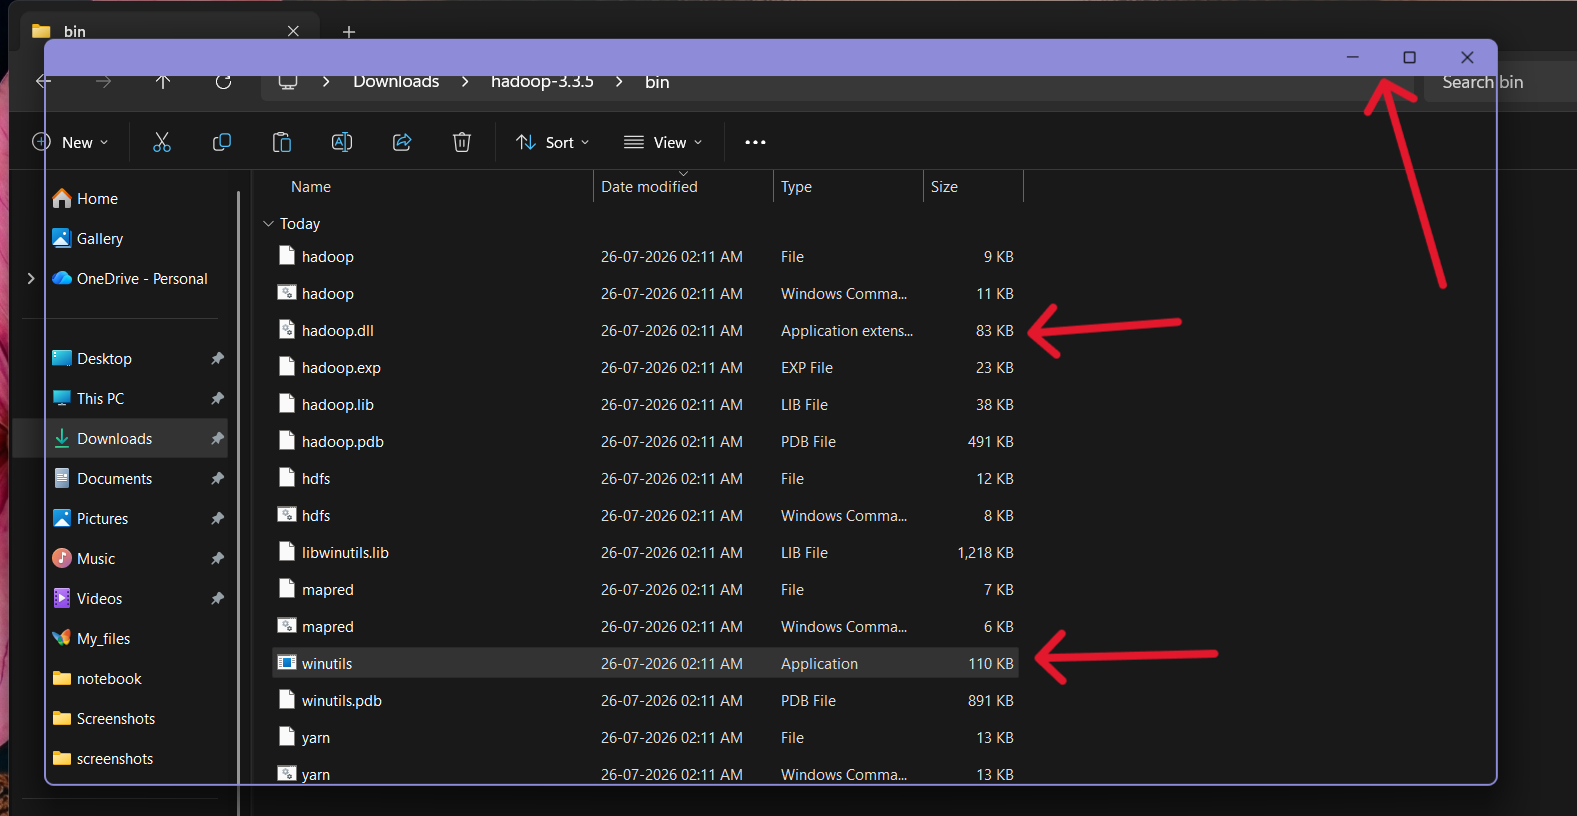